# Nematic Pair Potential — Demo

This notebook demonstrates `align_angle.NematicPair`, an anisotropic pair
potential that attracts particles with **parallel or anti-parallel** body-axis
orientations (nematic symmetry):

$$U_{ij} = -\epsilon \, (\hat{n}_i \cdot \hat{n}_j)^2 \left(1 - \frac{r_{ij}^2}{r_c^2}\right)^2$$

where $\hat{n} = \mathrm{rotate}(q, \hat{x})$ is the body-frame x-axis.

We simulate **1,000 soft particles** (DPD conservative repulsion) **confined
inside a sphere** and observe spontaneous **nematic ordering** — the emergence
of a global preferred axis from initially random orientations.

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import hoomd
from hoomd import align_angle

print("HOOMD version:", hoomd.version.version)
device = hoomd.device.auto_select()
print("Device:", device)

HOOMD version: 5.3.1
Device: <hoomd.device.GPU object at 0x7ff7f031d550>


## 1. Create a snapshot with 1000 particles

We place 1000 particles at **random positions inside a sphere** and give each
a random orientation. The HOOMD box must be large enough to contain the sphere.

In [41]:
N = 1000

# Sphere radius chosen to give a desired number density
density = 3.0
R_sphere = (3 * N / (4 * np.pi * density)) ** (1 / 3)

# The HOOMD box must be at least 2*R_sphere on each side
L = 2 * R_sphere + 4.0  # small margin
snap = hoomd.Snapshot()
snap.configuration.box = [L, L, L, 0, 0, 0]
snap.particles.N = N
snap.particles.types = ["A"]
snap.particles.typeid[:] = 0

# Random positions inside a slightly smaller sphere (avoid wall overlap)
rng = np.random.default_rng(42)
R_init = R_sphere - 1.5
positions = []
while len(positions) < N:
    pts = (rng.random((N, 3)) - 0.5) * 2 * R_init
    r2 = np.sum(pts**2, axis=1)
    inside = pts[r2 < R_init**2]
    positions.append(inside)
positions = np.vstack(positions)[:N]
snap.particles.position[:] = positions

# Random orientations (unit quaternions)
u = rng.normal(size=(N, 4))
u /= np.linalg.norm(u, axis=1, keepdims=True)
snap.particles.orientation[:] = u

# Needed for rotational integration
snap.particles.moment_inertia[:] = [1.0, 1.0, 1.0]

print(f"N = {N}, R_sphere = {R_sphere:.2f}, R_init = {R_init:.2f}, box L = {L:.2f}")
print(f"Number density = {N / (4/3 * np.pi * R_sphere**3):.3f}")
print(f"Positions shape: {snap.particles.position.shape}")
print(f"Orientations shape: {snap.particles.orientation.shape}")

N = 1000, R_sphere = 4.30, R_init = 2.80, box L = 12.60
Number density = 3.000
Positions shape: (1000, 3)
Orientations shape: (1000, 4)


## 2. Set up the simulation

We combine:
- **DPD conservative** soft repulsion: $F = A\,(r_c - r)$
- **NematicPair** attraction: $U = -\varepsilon\,(\hat n_i \cdot \hat n_j)^2\,(1 - r^2/r_c^2)^2$
- **LJ wall** on a sphere to confine particles

A Langevin thermostat controls temperature. We set `integrate_rotational_dof = True`
so orientations respond to the nematic torques.

In [42]:
sim = hoomd.Simulation(device=device, seed=12345)
sim.create_state_from_snapshot(snap)

# --- Forces ---
# 1) DPD conservative soft repulsion
cell = hoomd.md.nlist.Cell(buffer=0.4)
dpd_c = hoomd.md.pair.DPDConservative(nlist=cell, default_r_cut=1.0)
dpd_c.params[("A", "A")] = dict(A=25.0)

# 2) Nematic pair attraction
r_cut_nematic = 1.5
nematic = align_angle.NematicPair(nlist=cell, default_r_cut=r_cut_nematic)
nematic.params[("A", "A")] = dict(epsilon=4.0)

# 3) Spherical wall confinement (WCA-like: LJ with r_cut = 2^(1/6) sigma)
sphere_wall = hoomd.wall.Sphere(radius=R_sphere, inside=True)
wall_lj = hoomd.md.external.wall.LJ(walls=[sphere_wall])
wall_lj.params["A"] = dict(epsilon=5.0, sigma=1.0, r_cut=2 ** (1.0 / 6.0))

# --- Integrator ---
langevin = hoomd.md.methods.Langevin(filter=hoomd.filter.All(), kT=1.0)
integrator = hoomd.md.Integrator(
    dt=0.0001,
    methods=[langevin],
    forces=[dpd_c, nematic, wall_lj],
)
integrator.integrate_rotational_dof = True
sim.operations.integrator = integrator

# Warmup with tiny dt to resolve overlaps
print("Warmup with dt=0.0001 ...")
sim.run(5000)

# Ramp to production dt
integrator.dt = 0.005
print("Forces:", [f.__class__.__name__ for f in integrator.forces])
print("Rotational DOF:", integrator.integrate_rotational_dof)
print("Production dt:", integrator.dt)

Warmup with dt=0.0001 ...
Forces: ['DPDConservative', 'NematicPair', 'LJ']
Rotational DOF: True
Production dt: 0.005


## 3. Equilibrate & measure the nematic order parameter

The **nematic order parameter** $S$ is the largest eigenvalue of the
tensor order parameter:

$$Q_{\alpha\beta} = \frac{1}{N}\sum_{i=1}^{N}\left(\frac{3}{2}\,n_{i,\alpha}\,n_{i,\beta} - \frac{1}{2}\,\delta_{\alpha\beta}\right)$$

$S = 0$ means isotropic; $S = 1$ means perfect alignment.

In [43]:
def quat_to_director(q):
    """Convert quaternion (w, x, y, z) to body-frame x-axis in lab frame.
    
    This matches the evaluator: n = rotate(q, (1,0,0)).
    """
    w, x, y, z = q[..., 0], q[..., 1], q[..., 2], q[..., 3]
    nx = 1 - 2 * (y**2 + z**2)
    ny = 2 * (x * y + w * z)
    nz = 2 * (x * z - w * y)
    return np.stack([nx, ny, nz], axis=-1)


def nematic_order_parameter(orientations):
    """Compute S from the Q-tensor."""
    directors = quat_to_director(orientations)
    Q = np.zeros((3, 3))
    for alpha in range(3):
        for beta in range(3):
            Q[alpha, beta] = np.mean(
                1.5 * directors[:, alpha] * directors[:, beta]
                - 0.5 * (alpha == beta)
            )
    return np.max(np.linalg.eigvalsh(Q))


# --- Run and record S(t) ---
n_steps_total = 50_000
sample_period = 500
steps_list = []
S_list = []

for i in range(n_steps_total // sample_period):
    sim.run(sample_period)
    snap_now = sim.state.get_snapshot()
    ori = snap_now.particles.orientation
    S = nematic_order_parameter(ori)
    steps_list.append(sim.timestep)
    S_list.append(S)
    if (i + 1) % 20 == 0:
        print(f"  step {sim.timestep:>7d}  S = {S:.3f}")

steps_arr = np.array(steps_list)
S_arr = np.array(S_list)
print(f"\nFinal S = {S_arr[-1]:.3f}")

  step   15000  S = 0.999
  step   25000  S = 0.999
  step   35000  S = 0.999
  step   45000  S = 0.999
  step   55000  S = 0.999

Final S = 0.999


## 4. Plot the nematic order parameter over time

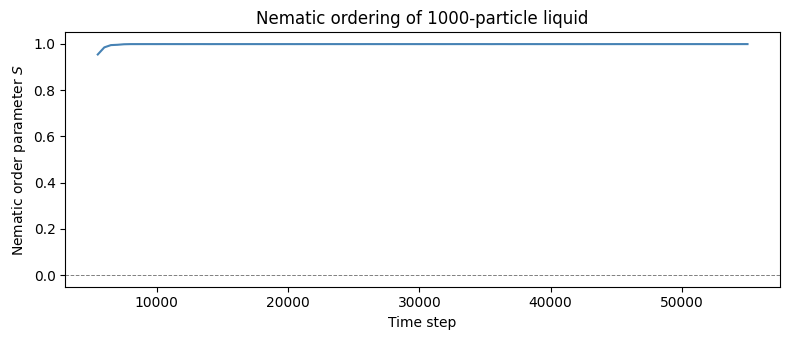

In [44]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(steps_arr, S_arr, lw=1.5, color="steelblue")
ax.set_xlabel("Time step")
ax.set_ylabel("Nematic order parameter $S$")
ax.set_ylim(-0.05, 1.05)
ax.axhline(0, color="gray", ls="--", lw=0.7)
ax.set_title("Nematic ordering of 1000-particle liquid")
fig.tight_layout()
plt.show()

## 5. 3D visualization with Plotly

Each particle is drawn as a cone pointing along its director $\hat n$.
Colour encodes the alignment with the nematic director (eigenvector of the
largest eigenvalue of $Q$).

In [45]:
import plotly.graph_objects as go

# Final snapshot
snap_final = sim.state.get_snapshot()
pos = np.array(snap_final.particles.position)
ori = np.array(snap_final.particles.orientation)
directors = quat_to_director(ori)

# Compute nematic director (eigenvector of Q)
Q = np.zeros((3, 3))
for a in range(3):
    for b in range(3):
        Q[a, b] = np.mean(1.5 * directors[:, a] * directors[:, b] - 0.5 * (a == b))
eigvals, eigvecs = np.linalg.eigh(Q)
nematic_director = eigvecs[:, np.argmax(eigvals)]

# cos^2(theta) with nematic director — measures alignment
cos2 = (directors @ nematic_director) ** 2

# Draw cones
cone_len = 0.5
fig = go.Figure()
fig.add_trace(go.Cone(
    x=pos[:, 0], y=pos[:, 1], z=pos[:, 2],
    u=directors[:, 0], v=directors[:, 1], w=directors[:, 2],
    sizemode="absolute",
    sizeref=cone_len,
    colorscale="RdYlBu",
    cmin=0, cmax=1,
    colorbar=dict(title="cos²θ"),
    anchor="center",
    showscale=True,
))

# Draw confining sphere wireframe
phi = np.linspace(0, 2 * np.pi, 40)
theta = np.linspace(0, np.pi, 20)
phi_g, theta_g = np.meshgrid(phi, theta)
xs = R_sphere * np.sin(theta_g) * np.cos(phi_g)
ys = R_sphere * np.sin(theta_g) * np.sin(phi_g)
zs = R_sphere * np.cos(theta_g)
fig.add_trace(go.Surface(
    x=xs, y=ys, z=zs,
    opacity=0.07,
    colorscale=[[0, "gray"], [1, "gray"]],
    showscale=False,
    hoverinfo="skip",
))

lim = R_sphere * 1.1
fig.update_layout(
    scene=dict(
        xaxis=dict(range=[-lim, lim]),
        yaxis=dict(range=[-lim, lim]),
        zaxis=dict(range=[-lim, lim]),
        aspectmode="cube",
    ),
    title=f"Nematic liquid in sphere — S = {S_arr[-1]:.3f}",
    width=700, height=700,
    margin=dict(l=0, r=0, t=40, b=0),
)
fig.show()

## 6. Distribution of pairwise alignment

Histogram of $|\hat n_i \cdot \hat n_j|$ for all neighbour pairs within the
nematic cutoff. In a nematic phase the distribution is sharply peaked near 1.

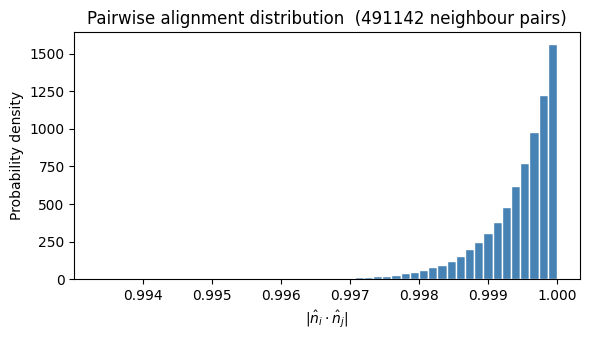

In [46]:
from scipy.spatial import cKDTree

# No periodic boundaries — just a plain KD-tree
tree = cKDTree(pos)
pairs = tree.query_pairs(r=r_cut_nematic, output_type="ndarray")

cos_ij = np.sum(directors[pairs[:, 0]] * directors[pairs[:, 1]], axis=1)
abs_cos_ij = np.abs(cos_ij)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(abs_cos_ij, bins=50, density=True, color="steelblue", edgecolor="white", lw=0.3)
ax.set_xlabel(r"$|\hat n_i \cdot \hat n_j|$")
ax.set_ylabel("Probability density")
ax.set_title(f"Pairwise alignment distribution  ({len(pairs)} neighbour pairs)")
fig.tight_layout()
plt.show()